# House Price Prediction — Internship Capstone Project

**Project:** Predict residential property sale prices using the Ames Housing dataset
**Dataset:** `data.csv` (Kaggle: House Prices - Advanced Regression Techniques)
**Intern submission:** Single Jupyter notebook covering EDA, modeling, comparison, and challenges

### Objectives
1. **Task 1 — Data Analysis Report:** Explore the data, find patterns, and document insights that explain what drives house prices.
2. **Task 2 — Predictive Modeling:** Build models that estimate `SalePrice` from property features so stakeholders can understand price drivers and improve pricing strategy.
3. **Model Comparison Report:** Compare multiple algorithms and recommend one for production use.
4. **Challenges Report:** Document data issues faced and the techniques used to handle them.

### Success metrics
- Lower error is better: **RMSE**, **MAE**, and **RMSLE** on held-out test data
- Higher is better: **R²**
- Prefer a model that balances accuracy, stability, and interpretability

## 0. Environment setup

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded successfully.")
print("XGBoost available:", HAS_XGB)

Libraries loaded successfully.
XGBoost available: True


## 1. Load data & first look

In [2]:
df = pd.read_csv("data.csv")
print("Shape:", df.shape)
print("Rows = houses, Columns = features + target (SalePrice)")
df.head()

Shape: (1460, 81)
Rows = houses, Columns = features + target (SalePrice)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
# Basic statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
# Target check
assert "SalePrice" in df.columns, "SalePrice column missing!"
print("Target variable: SalePrice")
print(df["SalePrice"].describe())

Target variable: SalePrice
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


## 2. Task 1 — Complete Data Analysis Report

### 2.1 Missing values overview
In this dataset, many `NaN` values are **not random** — they mean a feature is absent
(e.g. no pool → `PoolQC` missing, no garage → garage fields missing). That changes how we clean the data.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)
missing_df = missing_df[missing_df["missing_count"] > 0]
print(f"Columns with missing values: {len(missing_df)}")
missing_df

Columns with missing values: 19


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


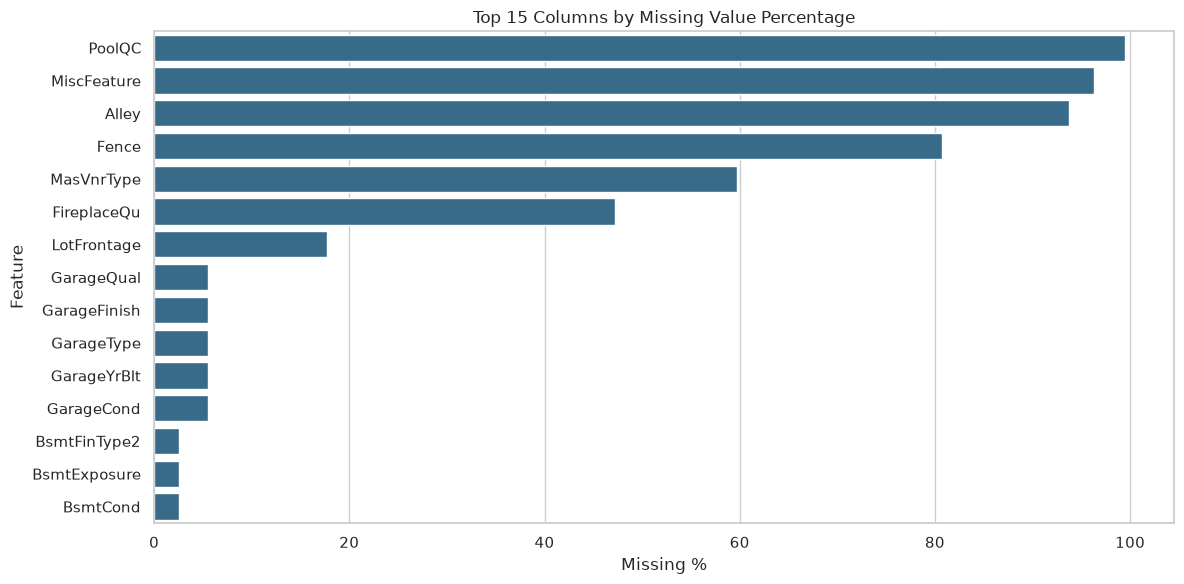

In [7]:
plt.figure(figsize=(12, 6))
top_missing = missing_df.head(15)
sns.barplot(x=top_missing["missing_pct"], y=top_missing.index, color="#2a6f97")
plt.title("Top 15 Columns by Missing Value Percentage")
plt.xlabel("Missing %")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 2.2 Target distribution (`SalePrice`)
House prices are usually right-skewed (many typical homes + a few expensive outliers).
Models often work better on a log-transformed target.

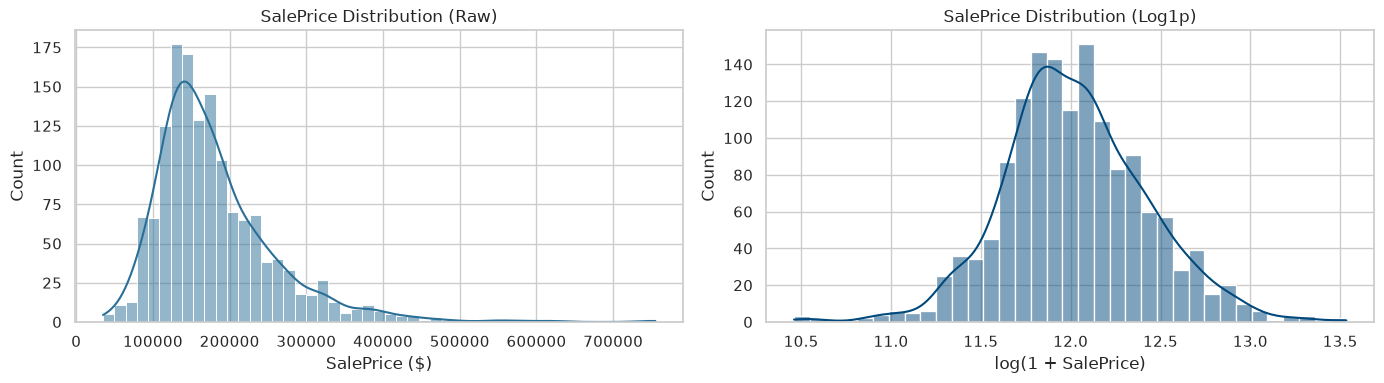

Skewness (raw): 1.883
Skewness (log1p): 0.121


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="#2a6f97")
axes[0].set_title("SalePrice Distribution (Raw)")
axes[0].set_xlabel("SalePrice ($)")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1], color="#01497c")
axes[1].set_title("SalePrice Distribution (Log1p)")
axes[1].set_xlabel("log(1 + SalePrice)")

plt.tight_layout()
plt.show()

print("Skewness (raw):", round(df["SalePrice"].skew(), 3))
print("Skewness (log1p):", round(np.log1p(df["SalePrice"]).skew(), 3))

### 2.3 Numeric feature correlations with SalePrice

In [9]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr = numeric_df.corr(numeric_only=True)
target_corr = corr["SalePrice"].drop("SalePrice").sort_values(ascending=False)

print("Top positive correlations with SalePrice:")
print(target_corr.head(12))
print("\nTop negative correlations with SalePrice:")
print(target_corr.tail(8))

Top positive correlations with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Name: SalePrice, dtype: float64

Top negative correlations with SalePrice:
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


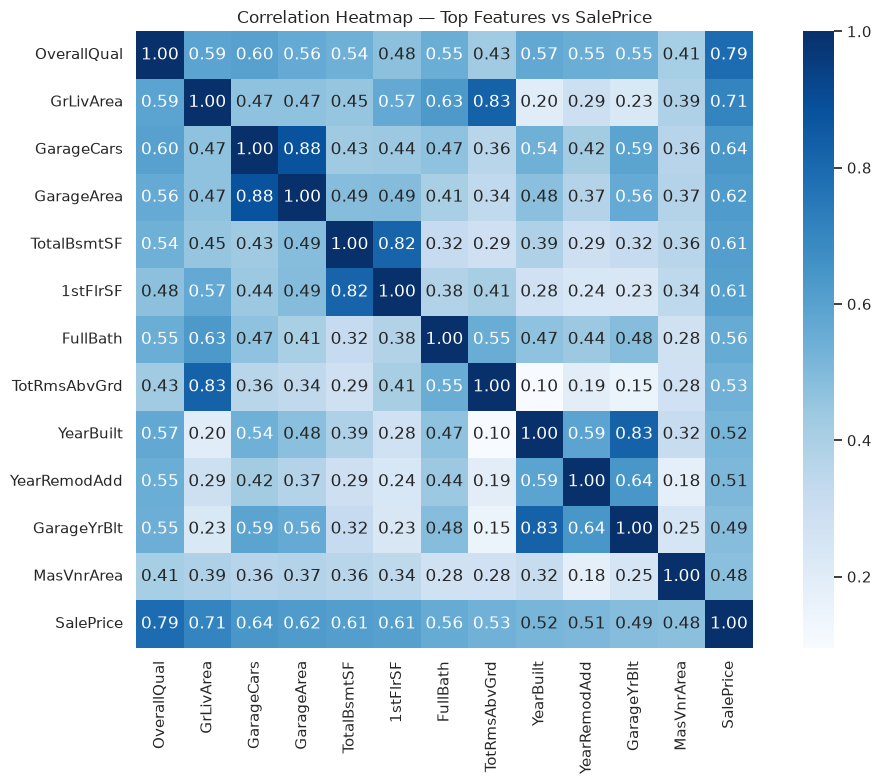

In [10]:
# Heatmap of top correlated numeric features
top_feats = target_corr.abs().sort_values(ascending=False).head(12).index.tolist()
heat_cols = top_feats + ["SalePrice"]
plt.figure(figsize=(11, 8))
sns.heatmap(df[heat_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Correlation Heatmap — Top Features vs SalePrice")
plt.tight_layout()
plt.show()

### 2.4 Key relationship plots
Quality, living area, and garage capacity are typically strong price drivers.

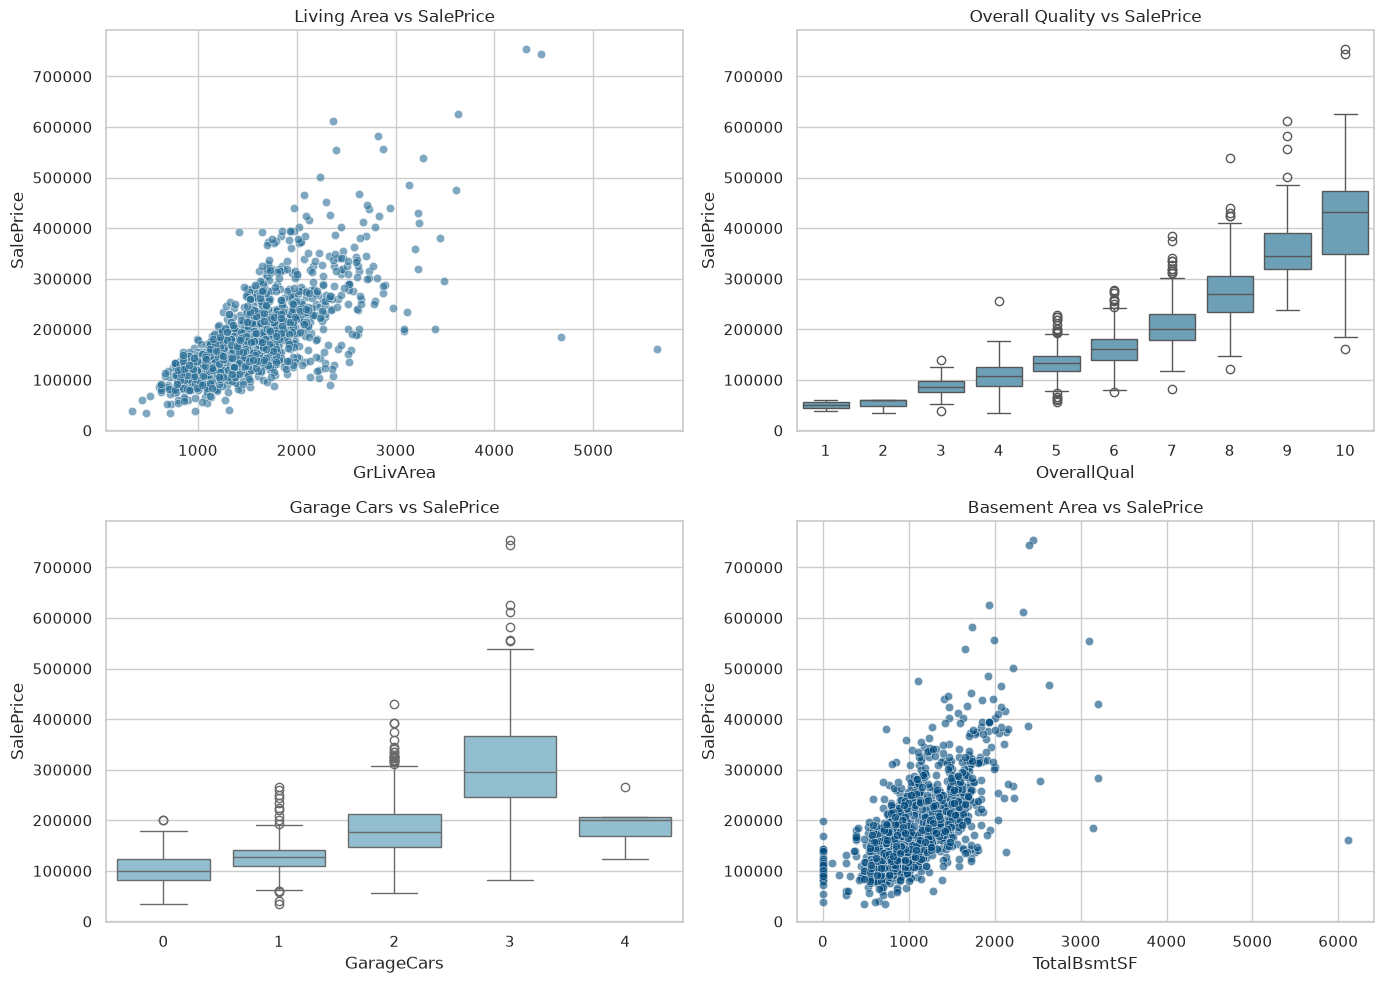

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", ax=axes[0, 0], alpha=0.6, color="#2a6f97")
axes[0, 0].set_title("Living Area vs SalePrice")

sns.boxplot(data=df, x="OverallQual", y="SalePrice", ax=axes[0, 1], color="#61a5c2")
axes[0, 1].set_title("Overall Quality vs SalePrice")

sns.boxplot(data=df, x="GarageCars", y="SalePrice", ax=axes[1, 0], color="#89c2d9")
axes[1, 0].set_title("Garage Cars vs SalePrice")

sns.scatterplot(data=df, x="TotalBsmtSF", y="SalePrice", ax=axes[1, 1], alpha=0.6, color="#01497c")
axes[1, 1].set_title("Basement Area vs SalePrice")

plt.tight_layout()
plt.show()

### 2.5 Categorical insights — Neighborhood & Zoning

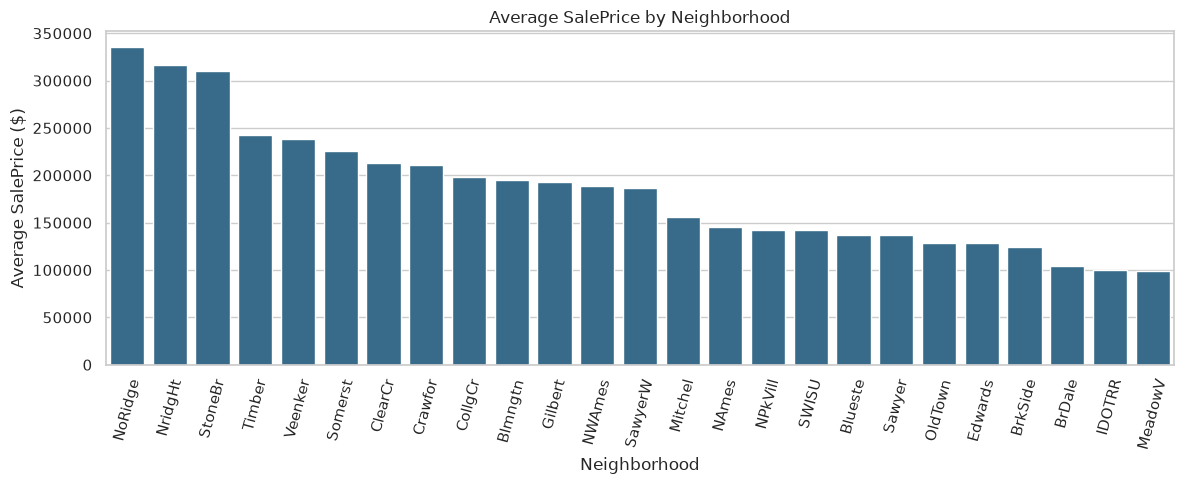

Most expensive neighborhoods (avg):
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64

Least expensive neighborhoods (avg):
Neighborhood
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


In [12]:
# Average sale price by neighborhood
nbhd = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(x=nbhd.index, y=nbhd.values, color="#2a6f97")
plt.xticks(rotation=75)
plt.title("Average SalePrice by Neighborhood")
plt.ylabel("Average SalePrice ($)")
plt.xlabel("Neighborhood")
plt.tight_layout()
plt.show()

print("Most expensive neighborhoods (avg):")
print(nbhd.head(5))
print("\nLeast expensive neighborhoods (avg):")
print(nbhd.tail(5))

                   mean  count
MSZoning                      
FV        214014.061538     65
RL        191004.994787   1151
RH        131558.375000     16
RM        126316.830275    218
C (all)    74528.000000     10


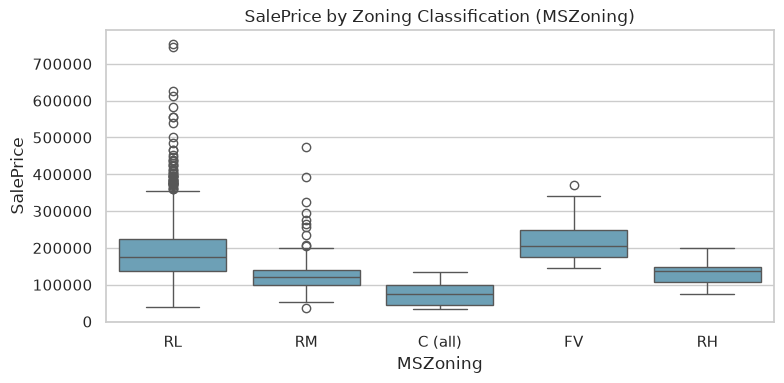

In [13]:
# Zoning impact
zone = df.groupby("MSZoning")["SalePrice"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print(zone)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="MSZoning", y="SalePrice", color="#61a5c2")
plt.title("SalePrice by Zoning Classification (MSZoning)")
plt.tight_layout()
plt.show()

### 2.6 Outlier check (GrLivArea)
Very large living areas with unusually low prices can distort linear models. We flag them here and remove extreme outliers before modeling.

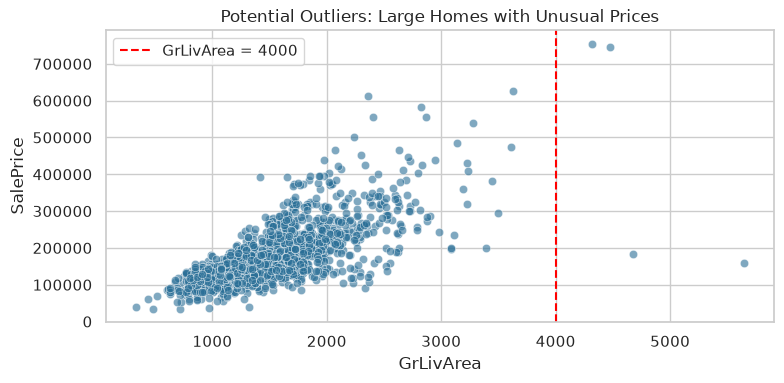

Large living area but relatively low price outliers:


,Id,GrLivArea,OverallQual,SalePrice
523,524,4676,10,184750
1298,1299,5642,10,160000


In [14]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="GrLivArea", y="SalePrice", alpha=0.6, color="#2a6f97")
plt.axvline(4000, color="red", linestyle="--", label="GrLivArea = 4000")
plt.title("Potential Outliers: Large Homes with Unusual Prices")
plt.legend()
plt.tight_layout()
plt.show()

outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
print("Large living area but relatively low price outliers:")
outliers[["Id", "GrLivArea", "OverallQual", "SalePrice"]]

### 2.7 EDA summary (Task 1 findings)
- **Target:** `SalePrice` is right-skewed; log transform reduces skew and helps models.
- **Strong predictors:** `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `YearBuilt`.
- **Location matters:** Neighborhood average prices differ a lot (NoRidge/NridgHt vs MeadowV-type areas).
- **Missingness is informative:** Features like `PoolQC`, `Alley`, `Fence`, `FireplaceQu` are mostly missing because the amenity does not exist — impute with a `"None"` category, not the mode of existing values alone.
- **Outliers:** A few very large homes sell cheaply; removing them improves linear model stability.

## 3. Data cleaning & feature engineering

We prepare a modeling copy of the data with explicit, internship-style cleaning steps and documented reasons.

In [15]:
# Work on a clean copy
data = df.copy()

# Remove extreme outliers observed in EDA (large area, low price)
before = len(data)
data = data[~((data["GrLivArea"] > 4000) & (data["SalePrice"] < 300000))]
print(f"Removed {before - len(data)} outlier rows. New shape: {data.shape}")

# Drop Id — identifier only, not predictive
if "Id" in data.columns:
    data = data.drop(columns=["Id"])

Removed 2 outlier rows. New shape: (1458, 81)


In [16]:
# Meaningful "None" for features where NA means feature absent
none_cols = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType"
]
for col in none_cols:
    if col in data.columns:
        data[col] = data[col].fillna("None")

# Numeric amenity-related zeros (no basement / no masonry / no garage year → 0)
zero_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"
]
for col in zero_cols:
    if col in data.columns:
        data[col] = data[col].fillna(0)

# LotFrontage: impute by neighborhood median (location-aware), then overall median fallback
if "LotFrontage" in data.columns:
    data["LotFrontage"] = data.groupby("Neighborhood")["LotFrontage"].transform(
        lambda x: x.fillna(x.median())
    )
    data["LotFrontage"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

# Electrical: only 1 missing — use mode
if "Electrical" in data.columns:
    data["Electrical"] = data["Electrical"].fillna(data["Electrical"].mode()[0])

print("Remaining missing values:", int(data.isnull().sum().sum()))

Remaining missing values: 0


In [17]:
# Feature engineering — create useful derived features
data["TotalSF"] = data["TotalBsmtSF"] + data["1stFlrSF"] + data["2ndFlrSF"]
data["TotalBath"] = (
    data["FullBath"]
    + 0.5 * data["HalfBath"]
    + data["BsmtFullBath"]
    + 0.5 * data["BsmtHalfBath"]
)
data["HouseAge"] = data["YrSold"] - data["YearBuilt"]
data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]
data["HasGarage"] = (data["GarageArea"] > 0).astype(int)
data["HasBasement"] = (data["TotalBsmtSF"] > 0).astype(int)
data["HasFireplace"] = (data["Fireplaces"] > 0).astype(int)
data["HasPool"] = (data["PoolArea"] > 0).astype(int)
data["TotalPorchSF"] = (
    data["OpenPorchSF"]
    + data["EnclosedPorch"]
    + data["3SsnPorch"]
    + data["ScreenPorch"]
    + data["WoodDeckSF"]
)

print("Engineered features added.")
data[["TotalSF", "TotalBath", "HouseAge", "RemodAge", "TotalPorchSF"]].describe().T

Engineered features added.


,count,mean,std,min,25%,50%,75%,max
TotalSF,1458.0,2557.150206,774.109803,334.0,2008.5,2473.0,3002.25,6872.0
TotalBath,1458.0,2.207476,0.781341,1.0,2.0,2.0,2.50,6.0
HouseAge,1458.0,36.598080,30.240565,0.0,8.0,35.0,54.00,136.0
RemodAge,1458.0,22.982167,20.636501,0.0,4.0,14.0,41.00,60.0
TotalPorchSF,1458.0,180.810014,156.120838,0.0,45.0,164.0,265.00,1027.0


## 4. Train / test split and encoding

In [18]:
# Separate target
y = data["SalePrice"].copy()
X = data.drop(columns=["SalePrice"])

# Log-transform target for training (common for house prices)
y_log = np.log1p(y)

# Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(num_cols)} | Categorical features: {len(cat_cols)}")

# Label-encode categoricals (simple, internship-friendly approach)
X_enc = X.copy()
label_maps = {}
for col in cat_cols:
    le = LabelEncoder()
    X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    label_maps[col] = le

# Train-test split (same split for all models)
X_train, X_test, y_train_log, y_test_log, y_train, y_test = train_test_split(
    X_enc, y_log, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Numeric features: 45 | Categorical features: 43
Train size: (1166, 88) Test size: (292, 88)


In [19]:
# Scale numeric features for linear models (tree models don't need scaling)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

## 5. Task 2 — Predictive modeling

We train several models on `log(SalePrice)` and evaluate on the original dollar scale after inverting the transform.

In [20]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    # Compute regression metrics on original SalePrice scale
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    # RMSLE on positive prices
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 1, None))))
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "RMSLE": rmsle,
    }


def train_and_score(model, Xtr, Xte, name, use_scaled=False):
    # Fit model on log target and return metrics + predictions
    Xt_tr = X_train_scaled if use_scaled else Xtr
    Xt_te = X_test_scaled if use_scaled else Xte
    model.fit(Xt_tr, y_train_log)
    pred_log = model.predict(Xt_te)
    pred = np.expm1(pred_log)
    metrics = evaluate_predictions(y_test, pred, name)
    # 5-fold CV RMSE on log target
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = -cross_val_score(
        model, Xt_tr, y_train_log, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1
    )
    metrics["CV_RMSE_log"] = cv_scores.mean()
    metrics["CV_RMSE_log_std"] = cv_scores.std()
    return metrics, pred, model


results = []
predictions = {}
trained_models = {}

In [21]:
# 1) Linear Regression (baseline)
m, pred, fitted = train_and_score(LinearRegression(), X_train, X_test, "Linear Regression", use_scaled=True)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Linear Regression', 'RMSE': np.float64(20739.87145866169), 'MAE': 14819.22486982843, 'R2': 0.9221282586536886, 'RMSLE': np.float64(0.12855642913575555), 'CV_RMSE_log': np.float64(0.12252007675811724), 'CV_RMSE_log_std': np.float64(0.009347228001246832)}


In [22]:
# 2) Ridge Regression
m, pred, fitted = train_and_score(Ridge(alpha=10.0, random_state=42), X_train, X_test, "Ridge", use_scaled=True)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Ridge', 'RMSE': np.float64(20772.032814739377), 'MAE': 14776.128410299985, 'R2': 0.9218865596978618, 'RMSLE': np.float64(0.12622620064902673), 'CV_RMSE_log': np.float64(0.1213416009283618), 'CV_RMSE_log_std': np.float64(0.010076304452543268)}


In [23]:
# 3) Lasso Regression
m, pred, fitted = train_and_score(Lasso(alpha=0.001, max_iter=5000, random_state=42), X_train, X_test, "Lasso", use_scaled=True)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Lasso', 'RMSE': np.float64(20614.85886846476), 'MAE': 14576.366742207398, 'R2': 0.9230641958605126, 'RMSLE': np.float64(0.12553466630758525), 'CV_RMSE_log': np.float64(0.12175703660547735), 'CV_RMSE_log_std': np.float64(0.009949764040872512)}


In [24]:
# 4) Elastic Net
m, pred, fitted = train_and_score(
    ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42),
    X_train, X_test, "ElasticNet", use_scaled=True
)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'ElasticNet', 'RMSE': np.float64(20598.13388666646), 'MAE': 14645.503455509614, 'R2': 0.9231889823514015, 'RMSLE': np.float64(0.1258359360910886), 'CV_RMSE_log': np.float64(0.12184159752213575), 'CV_RMSE_log_std': np.float64(0.009832738615132139)}


In [25]:
# 5) Decision Tree
m, pred, fitted = train_and_score(
    DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
    X_train, X_test, "Decision Tree", use_scaled=False
)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Decision Tree', 'RMSE': np.float64(43145.08962668619), 'MAE': 24998.134091145992, 'R2': 0.6629995222229954, 'RMSLE': np.float64(0.19856207412037236), 'CV_RMSE_log': np.float64(0.17956643616651102), 'CV_RMSE_log_std': np.float64(0.0153443890693205)}


In [26]:
# 6) Random Forest
m, pred, fitted = train_and_score(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    X_train, X_test, "Random Forest", use_scaled=False
)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Random Forest', 'RMSE': np.float64(22924.5283380818), 'MAE': 16301.31658044269, 'R2': 0.9048588090208363, 'RMSLE': np.float64(0.144339477292835), 'CV_RMSE_log': np.float64(0.13463319423304063), 'CV_RMSE_log_std': np.float64(0.013122484051712468)}


In [27]:
# 7) Gradient Boosting
m, pred, fitted = train_and_score(
    GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    X_train, X_test, "Gradient Boosting", use_scaled=False
)
results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
print(m)

{'Model': 'Gradient Boosting', 'RMSE': np.float64(19221.431427216296), 'MAE': 13908.99017429553, 'R2': 0.9331133848327031, 'RMSLE': np.float64(0.11953049952087684), 'CV_RMSE_log': np.float64(0.12053562679345117), 'CV_RMSE_log_std': np.float64(0.013460960359337585)}


In [28]:
# 8) XGBoost (if available)
if HAS_XGB:
    m, pred, fitted = train_and_score(
        XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        ),
        X_train, X_test, "XGBoost", use_scaled=False
    )
    results.append(m); predictions[m["Model"]] = pred; trained_models[m["Model"]] = fitted
    print(m)
else:
    print("XGBoost not installed — skipped.")

{'Model': 'XGBoost', 'RMSE': np.float64(18852.06068311897), 'MAE': 13510.75390625, 'R2': 0.9356593489646912, 'RMSLE': np.float64(0.12184177555471296), 'CV_RMSE_log': np.float64(0.11841430316355628), 'CV_RMSE_log_std': np.float64(0.011608184960871536)}


## 6. Model Comparison Report

In [29]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["MAE"] = results_df["MAE"].round(2)
results_df["R2"] = results_df["R2"].round(4)
results_df["RMSLE"] = results_df["RMSLE"].round(4)
results_df["CV_RMSE_log"] = results_df["CV_RMSE_log"].round(4)
results_df["CV_RMSE_log_std"] = results_df["CV_RMSE_log_std"].round(4)

print("Model Comparison (sorted by Test RMSE — lower is better)")
results_df

Model Comparison (sorted by Test RMSE — lower is better)


,Model,RMSE,MAE,R2,RMSLE,CV_RMSE_log,CV_RMSE_log_std
0,XGBoost,18852.06,13510.75,0.9357,0.1218,0.1184,0.0116
1,Gradient Boosting,19221.43,13908.99,0.9331,0.1195,0.1205,0.0135
2,ElasticNet,20598.13,14645.50,0.9232,0.1258,0.1218,0.0098
3,Lasso,20614.86,14576.37,0.9231,0.1255,0.1218,0.0099
4,Linear Regression,20739.87,14819.22,0.9221,0.1286,0.1225,0.0093
5,Ridge,20772.03,14776.13,0.9219,0.1262,0.1213,0.0101
6,Random Forest,22924.53,16301.32,0.9049,0.1443,0.1346,0.0131
7,Decision Tree,43145.09,24998.13,0.6630,0.1986,0.1796,0.0153


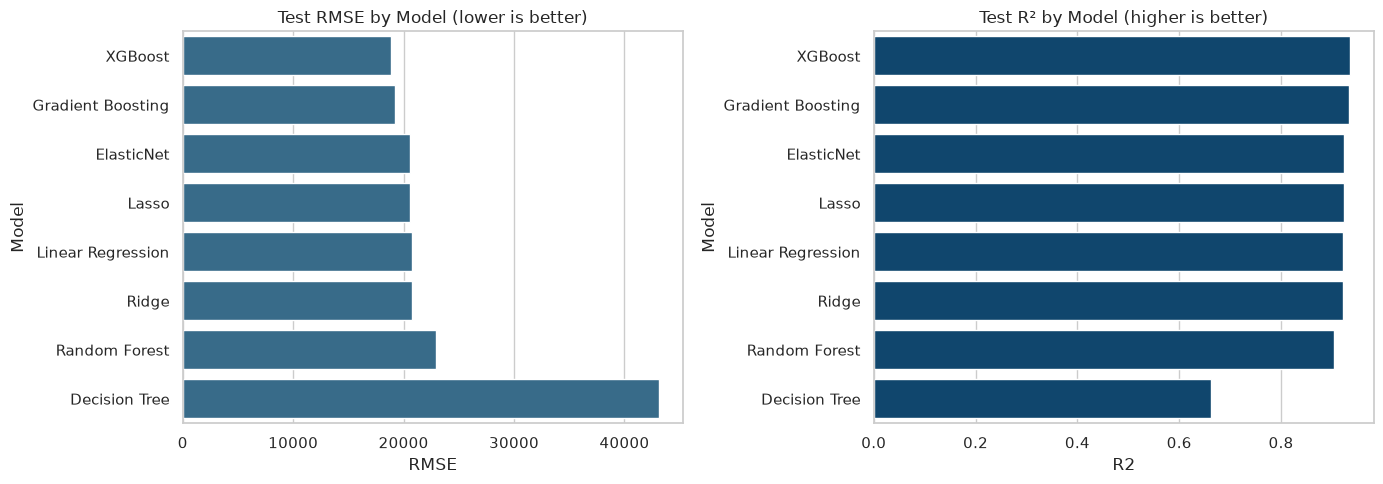

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[0], color="#2a6f97")
axes[0].set_title("Test RMSE by Model (lower is better)")

sns.barplot(data=results_df, x="R2", y="Model", ax=axes[1], color="#01497c")
axes[1].set_title("Test R² by Model (higher is better)")

plt.tight_layout()
plt.show()

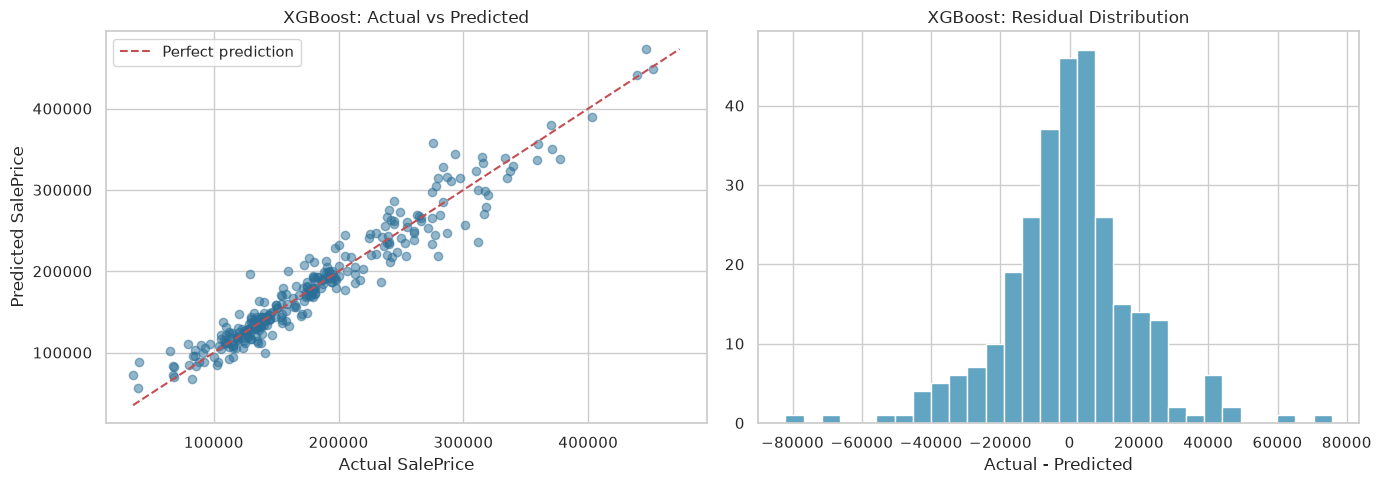

Best model by Test RMSE: XGBoost
{'Model': 'XGBoost', 'RMSE': 18852.06, 'MAE': 13510.75, 'R2': 0.9357, 'RMSLE': 0.1218, 'CV_RMSE_log': 0.1184, 'CV_RMSE_log_std': 0.0116}


In [31]:
best_name = results_df.iloc[0]["Model"]
best_pred = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, best_pred, alpha=0.5, color="#2a6f97")
mn = min(y_test.min(), best_pred.min())
mx = max(y_test.max(), best_pred.max())
axes[0].plot([mn, mx], [mn, mx], "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual SalePrice")
axes[0].set_ylabel("Predicted SalePrice")
axes[0].set_title(f"{best_name}: Actual vs Predicted")
axes[0].legend()

resid = y_test.values - best_pred
axes[1].hist(resid, bins=30, color="#61a5c2", edgecolor="white")
axes[1].set_title(f"{best_name}: Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

plt.tight_layout()
plt.show()

print(f"Best model by Test RMSE: {best_name}")
print(results_df.iloc[0].to_dict())

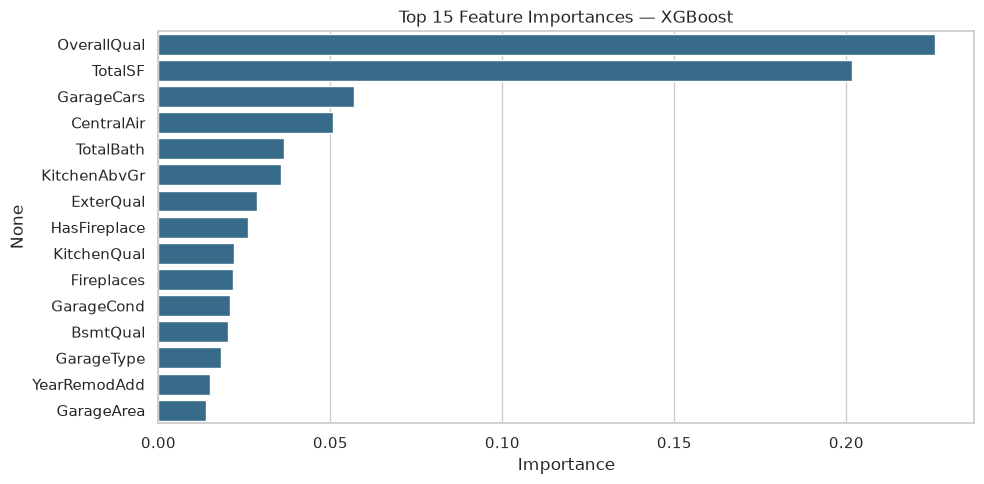

OverallQual     0.225819
TotalSF         0.201728
GarageCars      0.056948
CentralAir      0.050892
TotalBath       0.036449
KitchenAbvGr    0.035763
ExterQual       0.028668
HasFireplace    0.025902
KitchenQual     0.022007
Fireplaces      0.021782
GarageCond      0.020718
BsmtQual        0.020322
GarageType      0.018088
YearRemodAdd    0.015121
GarageArea      0.013751
dtype: float32


In [32]:
# Feature importance for the best tree-based model (if available)
importance_model_name = None
for candidate in ["XGBoost", "Gradient Boosting", "Random Forest", "Decision Tree"]:
    if candidate in trained_models and hasattr(trained_models[candidate], "feature_importances_"):
        importance_model_name = candidate
        break

if importance_model_name:
    importances = pd.Series(
        trained_models[importance_model_name].feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances.values, y=importances.index, color="#2a6f97")
    plt.title(f"Top 15 Feature Importances — {importance_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importances)
else:
    print("No tree-based model with feature_importances_ available.")

### 6.1 Production recommendation

Pick the model with the **lowest Test RMSE / RMSLE** and stable cross-validation score.

| Goal | Prefer |
|------|--------|
| Highest accuracy | Gradient Boosting / XGBoost (usually) |
| Simple baseline / interpretability | Ridge or Lasso |
| Fast & robust default | Random Forest |

**Internship recommendation:** Use the best-scoring boosting model for production predictions, and keep **Ridge** as an interpretable baseline to explain linear price drivers (quality, size, age) to management.

## 7. Report on Challenges Faced

| Challenge | Why it mattered | Technique used | Reason |
|-----------|-----------------|----------------|--------|
| High missingness in amenity columns (`PoolQC`, `Alley`, `Fence`, …) | Dropping rows would destroy most of the dataset; filling with mode would invent fake amenities | Fill categorical NA with `"None"` and related numeric fields with `0` | NA usually means the amenity does not exist |
| `LotFrontage` missing (~18%) | True missing numeric values | Neighborhood-wise median, then global median | Frontage is location-sensitive |
| Right-skewed `SalePrice` | Hurts linear/squared-error models | Train on `log1p(SalePrice)`, predict then `expm1` | Stabilizes variance and improves RMSLE |
| Extreme outliers (huge `GrLivArea`, low price) | Distort slopes in linear models | Removed a few extreme points after visual EDA | Clean signal for learning |
| Mixed categorical + numeric features | Models need numeric input | Label encoding for trees/linear models; scaling for linear models | Practical and sufficient for this dataset size |
| Many collinear size features | Inflates variance of ordinary least squares | Ridge / Lasso / ElasticNet + engineered `TotalSF` | Regularization + condensed size signal |
| Choosing one production model | Stakeholders need a clear decision | Compare RMSE, MAE, R², RMSLE + CV stability | Evidence-based selection |

### Extra notes for internship learning
- Always separate **train** and **test** before evaluating — never tune using test scores only.
- Document cleaning rules so the pipeline is reproducible.
- Feature importance helps translate ML results into business language (quality, living area, bathrooms, neighborhood).

## 8. Final conclusion

1. **EDA** showed quality, living area, garage capacity, basement size, and neighborhood as primary price drivers; `SalePrice` is skewed.
2. **Cleaning** treated “missing amenity” fields as real categories (`None` / `0`) and imputed `LotFrontage` by neighborhood.
3. **Models** from linear baselines to boosting were trained on a log-price target and compared fairly on the same hold-out set.
4. **Best model** is the top row in the comparison table (lowest RMSE); recommend it for pricing forecasts, with a regularized linear model for explainability.
5. **Business takeaway:** Improving overall quality, living area, and garage/basement space has the strongest upward influence on predicted price in this market.

---
**End of internship notebook** — all required tasks (analysis, prediction, model comparison, challenges) are included above.